<p>
  <img src="https://upload.wikimedia.org/wikipedia/commons/f/fb/Escudo-UdeA.svg"
       alt="UdeA logo"
       height="190px"
       align="left"
       hspace="15px">
</p>

<h1 style="margin-top: 20px;"><b>Homework 2: Student's t-Distribution</b></h1>

<hr>

<div align="right" style="font-size: 14px; line-height: 1.4;">
  <b>Estiven Castrillon Alzate</b><br>
  Institute of Physics<br>
  <i>Universidad de Antioquia</i><br>
  <span style="font-size: 12px;">Date: October 23, 2024</span>
</div>

<br><br>

## Summary

This notebook presents a comprehensive analysis of gravitational acceleration determination using a simple pendulum with two distinct measurement methods: a stopwatch and a photogate sensor connected to an Arduino platform.

### Experimental Setup

The experiment involved measuring the oscillation period of a pendulum with constant length (0.668 m) across two measurement approaches:
- Stopwatch method: Manual timing of 30 oscillations, accounting for human reaction time delay of 0.25 s
- Photogate method: Automated electronic timing providing higher precision and eliminating systematic human errors

### Data Processing and Analysis

Initial data from the stopwatch measurements showed significant outliers, which were filtered to retain values between 1.3 and 1.6 seconds. This preprocessing step was crucial for improving the reliability of subsequent calculations.

Using the formula $$g = \frac{4\pi^2 L}{T^2}$$, the acceleration due to gravity was calculated for each period measurement. The data were then grouped into sets of 5, 15, and 30 samples to evaluate how sample size affects the accuracy of gravity determination.

### Error Analysis

For each data group, we calculated:
- Average acceleration and standard error
- Confidence intervals using one standard error, three standard errors, and t-student correction (0.27% uncertainty)
- Percentage error relative to the accepted value for Medellín $(g = 977 cm/s² = 9.77 m/s²)$

### Key Findings

The photogate measurements consistently outperformed the stopwatch method, demonstrating:
- Smaller percentage errors across all group sizes
- More reliable and coherent results
- Better agreement with the theoretical acceleration due to gravity

The results validate that systematic errors in manual timing significantly impact measurements, while automated measurement techniques provide substantially improved accuracy for gravitational acceleration determination.

### Conclusion

The photogate method proved to be the superior approach for this experiment, delivering the lowest percentage error and most reliable determination of gravitational acceleration with the t-student correction for 0.27% uncertainty.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from warnings import filterwarnings
filterwarnings("ignore")

# Advanced Seaborn configuration for scientific plots
sns.set_theme(
    context="talk",
    style="whitegrid",
    palette="deep",
    rc={
        "lines.linewidth": 2.5,
        "figure.dpi": 150,  # Improves plot quality
        "savefig.dpi": 300,  # High-resolution export
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 14,
        "axes.grid": True,
        "grid.alpha": 0.6,
        "grid.linestyle": "--",
        "grid.color": "gray",
        "axes.edgecolor": "black",
        "axes.linewidth": 1.2,
        "font.family": "serif",  # Better readability in papers
        "mathtext.fontset": "stix",  # Font for mathematical expressions
    }
)

# Extra configuration for Matplotlib
plt.rcParams.update({
    "figure.figsize": (14, 8),
    "axes.spines.top": False,  # Remove top border
    "axes.spines.right": False,  # Remove right border
    "xtick.direction": "inout",
    "ytick.direction": "inout",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.major.width": 1,
    "ytick.major.width": 1,
    "legend.frameon": False,  # Transparent background for legend
    "legend.loc": "best",  # Automatic optimal position
})

Activity 2 (recorded in the logbook)

Free fall experiment (Continuous distributions and confidence intervals)

This activity aims to strengthen the concepts of continuous distributions and confidence intervals when we have limited data in an experimental measurement.

Data collection I: Using a measuring tape, a ruler, and a stopwatch, drop an object from a fixed height and measure (using the stopwatch) the time it takes to touch the ground. Repeat this procedure 30 times.

Determine the mean of the fall times and plot the residual with respect to the mean. Are your data random? If you detect any skewed value that you consider was a human error, repeat it, redetermine the mean, the residuals, and plot again (do not delete the previous plot for comparison purposes).

Use the equation for the acceleration due to gravity as a function of height to determine the acceleration due to gravity for each time. Group the accelerations into groups of 5, 15, and 30 data (randomly selected) and perform the following steps with each group:

Determine the average acceleration and standard error.

In the same figure, plot the average value with error bars of one standard error, 3 standard errors, and with the t-student correction for an uncertainty of 0.27%. Include in the plot the accepted value for acceleration g = 977 cm/s². Analyze and conclude about the result for each group and each reported error.

Determine the percentage error of the central value for each group with respect to the expected value for Medellín. Analyze and conclude.

Data collection II. In order to eliminate possible human errors during data collection, we can use the Phyphox application to measure fall times (see video until minute 2:20 Smartphone-Experiment: Free fall (en)). Repeat points 2, 3, and 4 with the new measurements. Do you notice any improvement with respect to the previous results? Conclude. You can also propose another procedure that reduces the effect of human errors.

Finally, report the acceleration value you obtained with the lowest percentage error and with the t-student correction for an uncertainty of 0.27%.

Deliver a notebook with the answer to each of these points. Include for points 1 and 5 a brief description (with photographic evidence) of the experimental setup and the data collected.

In [2]:
stopwatch_data = pd.read_json('{"angle(degrees)":{"0":10,"1":10,"2":10,"3":10,"4":10,"5":10,"6":10,"7":10,"8":10,"9":10,"10":10,"11":10,"12":10,"13":10,"14":10,"15":10,"16":10,"17":10,"18":10,"19":10,"20":10,"21":10,"22":10,"23":10,"24":10,"25":10,"26":10,"27":10,"28":10,"29":10,"30":5,"31":5,"32":5,"33":5,"34":5,"35":5,"36":5,"37":5,"38":5,"39":5,"40":5,"41":5,"42":5,"43":5,"44":5,"45":5,"46":5,"47":5,"48":5,"49":5,"50":5,"51":5,"52":5,"53":5,"54":5,"55":5,"56":5,"57":5,"58":5,"59":5,"60":15,"61":15,"62":15,"63":15,"64":15,"65":15,"66":15,"67":15,"68":15,"69":15,"70":15,"71":15,"72":15,"73":15,"74":15,"75":15,"76":15,"77":15,"78":15,"79":15,"80":15,"81":15,"82":15,"83":15,"84":15,"85":15,"86":15,"87":15,"88":15,"89":15},"period(seconds)":{"0":1.27,"1":1.36,"2":1.38,"3":1.37,"4":1.39,"5":1.5,"6":1.4,"7":1.46,"8":1.55,"9":1.38,"10":1.45,"11":1.42,"12":1.54,"13":1.57,"14":1.5,"15":1.63,"16":1.4,"17":1.42,"18":1.55,"19":1.46,"20":1.41,"21":1.53,"22":1.34,"23":1.49,"24":1.4,"25":1.53,"26":1.54,"27":1.52,"28":1.44,"29":1.42,"30":1.49,"31":1.51,"32":1.56,"33":1.34,"34":1.38,"35":1.5,"36":1.4,"37":1.69,"38":1.5,"39":1.64,"40":1.63,"41":1.39,"42":1.26,"43":1.4,"44":1.48,"45":1.37,"46":1.55,"47":1.45,"48":1.44,"49":1.38,"50":1.5,"51":1.46,"52":1.36,"53":1.47,"54":1.34,"55":1.44,"56":1.49,"57":1.45,"58":1.46,"59":1.39,"60":1.46,"61":1.49,"62":1.5,"63":1.52,"64":1.5,"65":1.63,"66":1.56,"67":1.6,"68":1.56,"69":1.5,"70":1.54,"71":1.45,"72":1.5,"73":1.51,"74":1.51,"75":1.5,"76":1.45,"77":1.58,"78":1.36,"79":1.52,"80":1.53,"81":1.55,"82":1.57,"83":1.49,"84":1.54,"85":1.43,"86":1.52,"87":1.54,"88":1.61,"89":1.51}}')
photogate_data = pd.read_json('{"angle(degrees)":{"0":15,"1":15,"2":15,"3":15,"4":15,"5":15,"6":15,"7":15,"8":15,"9":15,"10":15,"11":15,"12":15,"13":15,"14":15,"15":15,"16":15,"17":15,"18":15,"19":15,"20":15,"21":15,"22":15,"23":15,"24":15,"25":15,"26":15,"27":15,"28":15,"29":15,"30":10,"31":10,"32":10,"33":10,"34":10,"35":10,"36":10,"37":10,"38":10,"39":10,"40":10,"41":10,"42":10,"43":10,"44":10,"45":10,"46":10,"47":10,"48":10,"49":10,"50":10,"51":10,"52":10,"53":10,"54":10,"55":10,"56":10,"57":10,"58":10,"59":10},"period(seconds)":{"0":1.608687,"1":1.614224,"2":1.602636,"3":1.595283,"4":1.597941,"5":1.599434,"6":1.607294,"7":1.595343,"8":1.601437,"9":1.602399,"10":1.598438,"11":1.590826,"12":1.597024,"13":1.596517,"14":1.592389,"15":1.577444,"16":1.597029,"17":1.606707,"18":1.58779,"19":1.596261,"20":1.596588,"21":1.593822,"22":1.575884,"23":1.584727,"24":1.575937,"25":1.586406,"26":1.57594,"27":1.58601,"28":1.575604,"29":1.584229,"30":1.590607,"31":1.587191,"32":1.635493,"33":1.586317,"34":1.593918,"35":1.607376,"36":1.59274,"37":1.603261,"38":1.628073,"39":1.588067,"40":1.561282,"41":1.575551,"42":1.563065,"43":1.599565,"44":1.628174,"45":1.588863,"46":1.560299,"47":1.575968,"48":1.559681,"49":1.596712,"50":1.60462,"51":1.593906,"52":1.577525,"53":1.559053,"54":1.576672,"55":1.558184,"56":1.59515,"57":1.591237,"58":1.558698,"59":1.577091}}')

In [3]:
print(f"Stopwatch data with shape {stopwatch_data.shape}:")
display(stopwatch_data.head(2))

print(f"Photogate data with shape {photogate_data.shape}:")
display(photogate_data.head(2))

Stopwatch data with shape (90, 2):


,angle(degrees),period(seconds)
0,10,1.27
1,10,1.36


Photogate data with shape (60, 2):


,angle(degrees),period(seconds)
0,15,1.608687
1,15,1.614224


# Points 1 and 2

1. Using the expression g = 4π²·L/T², where g is the acceleration due to gravity and L is the length of a simple pendulum that oscillates with period T, measure the period 30 times, always starting the motion from the same height using a stopwatch or the photogate connected to the Arduino platform. Remember that if you use sight to trigger the stopwatch when the object completes one oscillation, there is a delay in muscular response of 0.25 s.

2. Determine the mean of the periods and plot the residual with respect to the mean. Are your data random? If you detect any skewed value that you consider was a human error, remove it, redetermine the mean, the residuals, and plot again (do not delete the previous plot for comparison purposes).

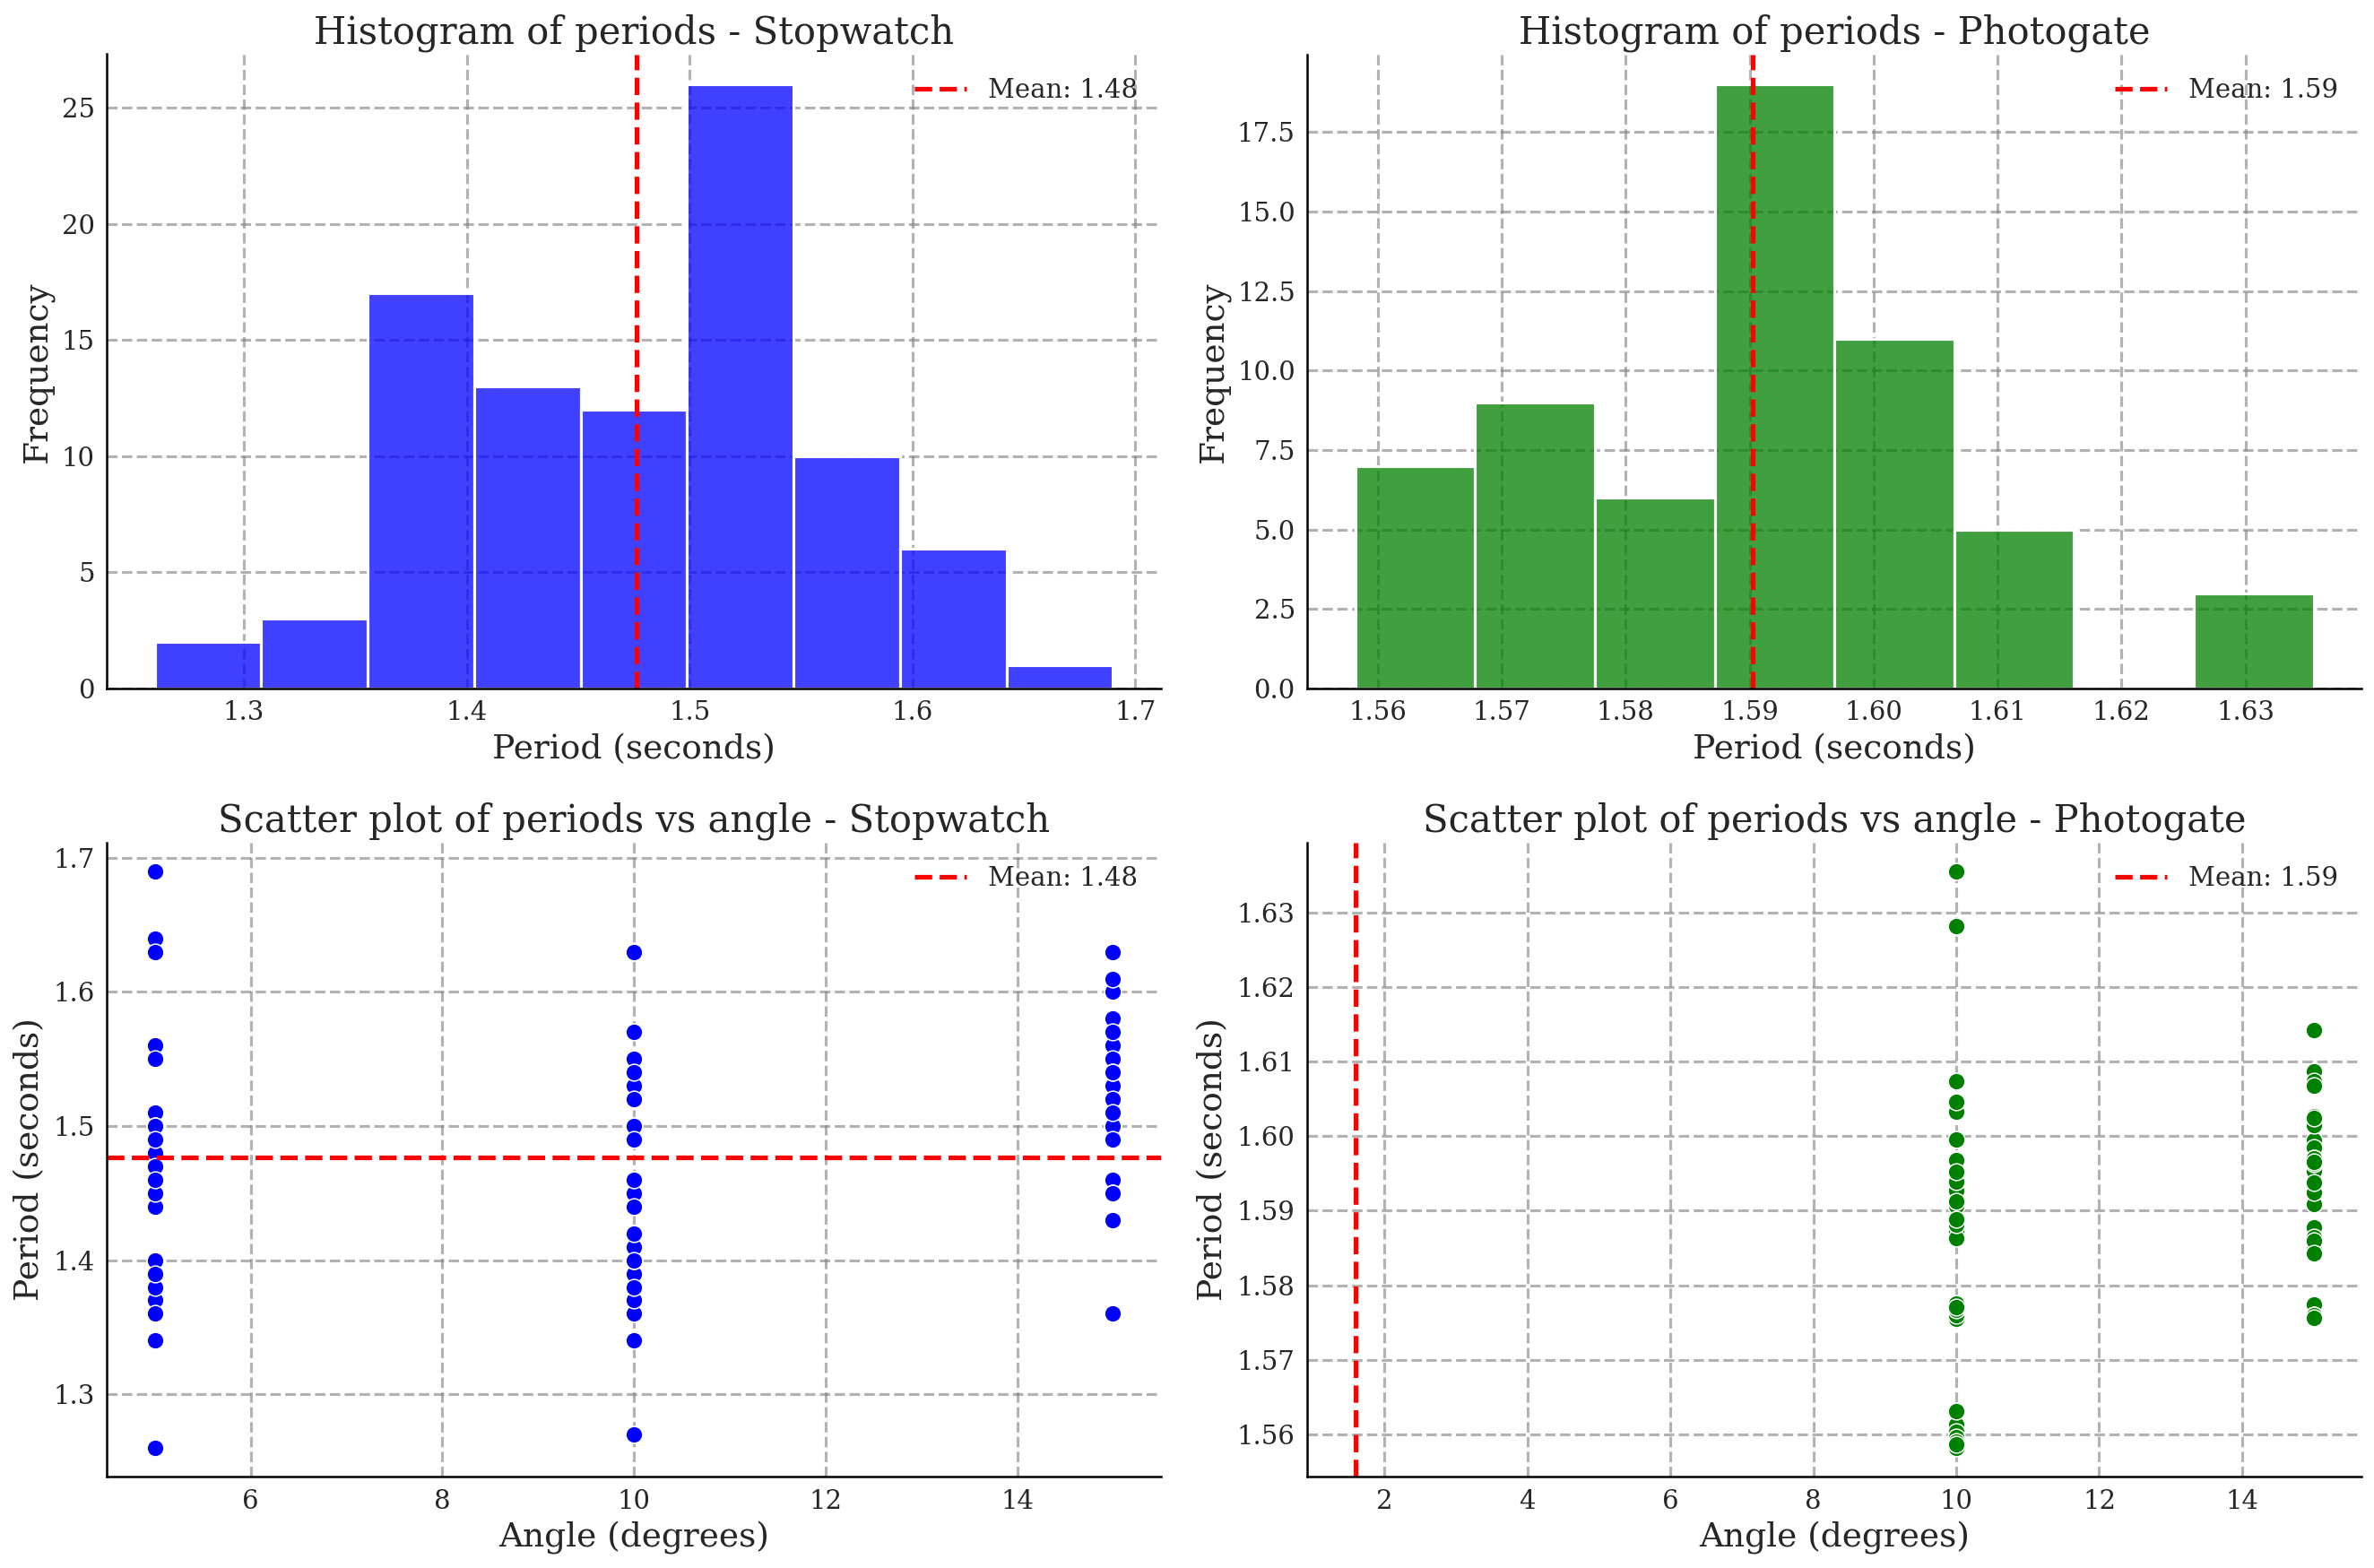

In [4]:
# Calculate the period means
mean_stopwatch = stopwatch_data['period(seconds)'].mean()
mean_photogate = photogate_data['period(seconds)'].mean()

# Create a figure with 4 subplots
plt.figure(figsize=(18, 12))

# Histogram of stopwatch_data
plt.subplot(2, 2, 1)
sns.histplot(stopwatch_data['period(seconds)'], kde=False, color='blue')
plt.axvline(mean_stopwatch, color='red', linestyle='--', label=f'Mean: {mean_stopwatch:.2f}')
plt.title('Histogram of periods - Stopwatch')
plt.xlabel('Period (seconds)')
plt.ylabel('Frequency')
plt.legend()

# Histogram of photogate_data
plt.subplot(2, 2, 2)
sns.histplot(photogate_data['period(seconds)'], kde=False, color='green')
plt.axvline(mean_photogate, color='red', linestyle='--', label=f'Mean: {mean_photogate:.2f}')
plt.title('Histogram of periods - Photogate')
plt.xlabel('Period (seconds)')
plt.ylabel('Frequency')
plt.legend()

# Scatter plot of stopwatch_data
plt.subplot(2, 2, 3)
sns.scatterplot(x=stopwatch_data['angle(degrees)'], y=stopwatch_data['period(seconds)'], color='blue')
plt.axhline(mean_stopwatch, color='red', linestyle='--', label=f'Mean: {mean_stopwatch:.2f}')
plt.title('Scatter plot of periods vs angle - Stopwatch')
plt.xlabel('Angle (degrees)')
plt.ylabel('Period (seconds)')
plt.legend()

# Scatter plot of photogate_data
plt.subplot(2, 2, 4)
sns.scatterplot(x=photogate_data['angle(degrees)'], y=photogate_data['period(seconds)'], color='green')
plt.axvline(mean_photogate, color='red', linestyle='--', label=f'Mean: {mean_photogate:.2f}')
plt.title('Scatter plot of periods vs angle - Photogate')
plt.xlabel('Angle (degrees)')
plt.ylabel('Period (seconds)')
plt.legend()

plt.tight_layout()
plt.show()

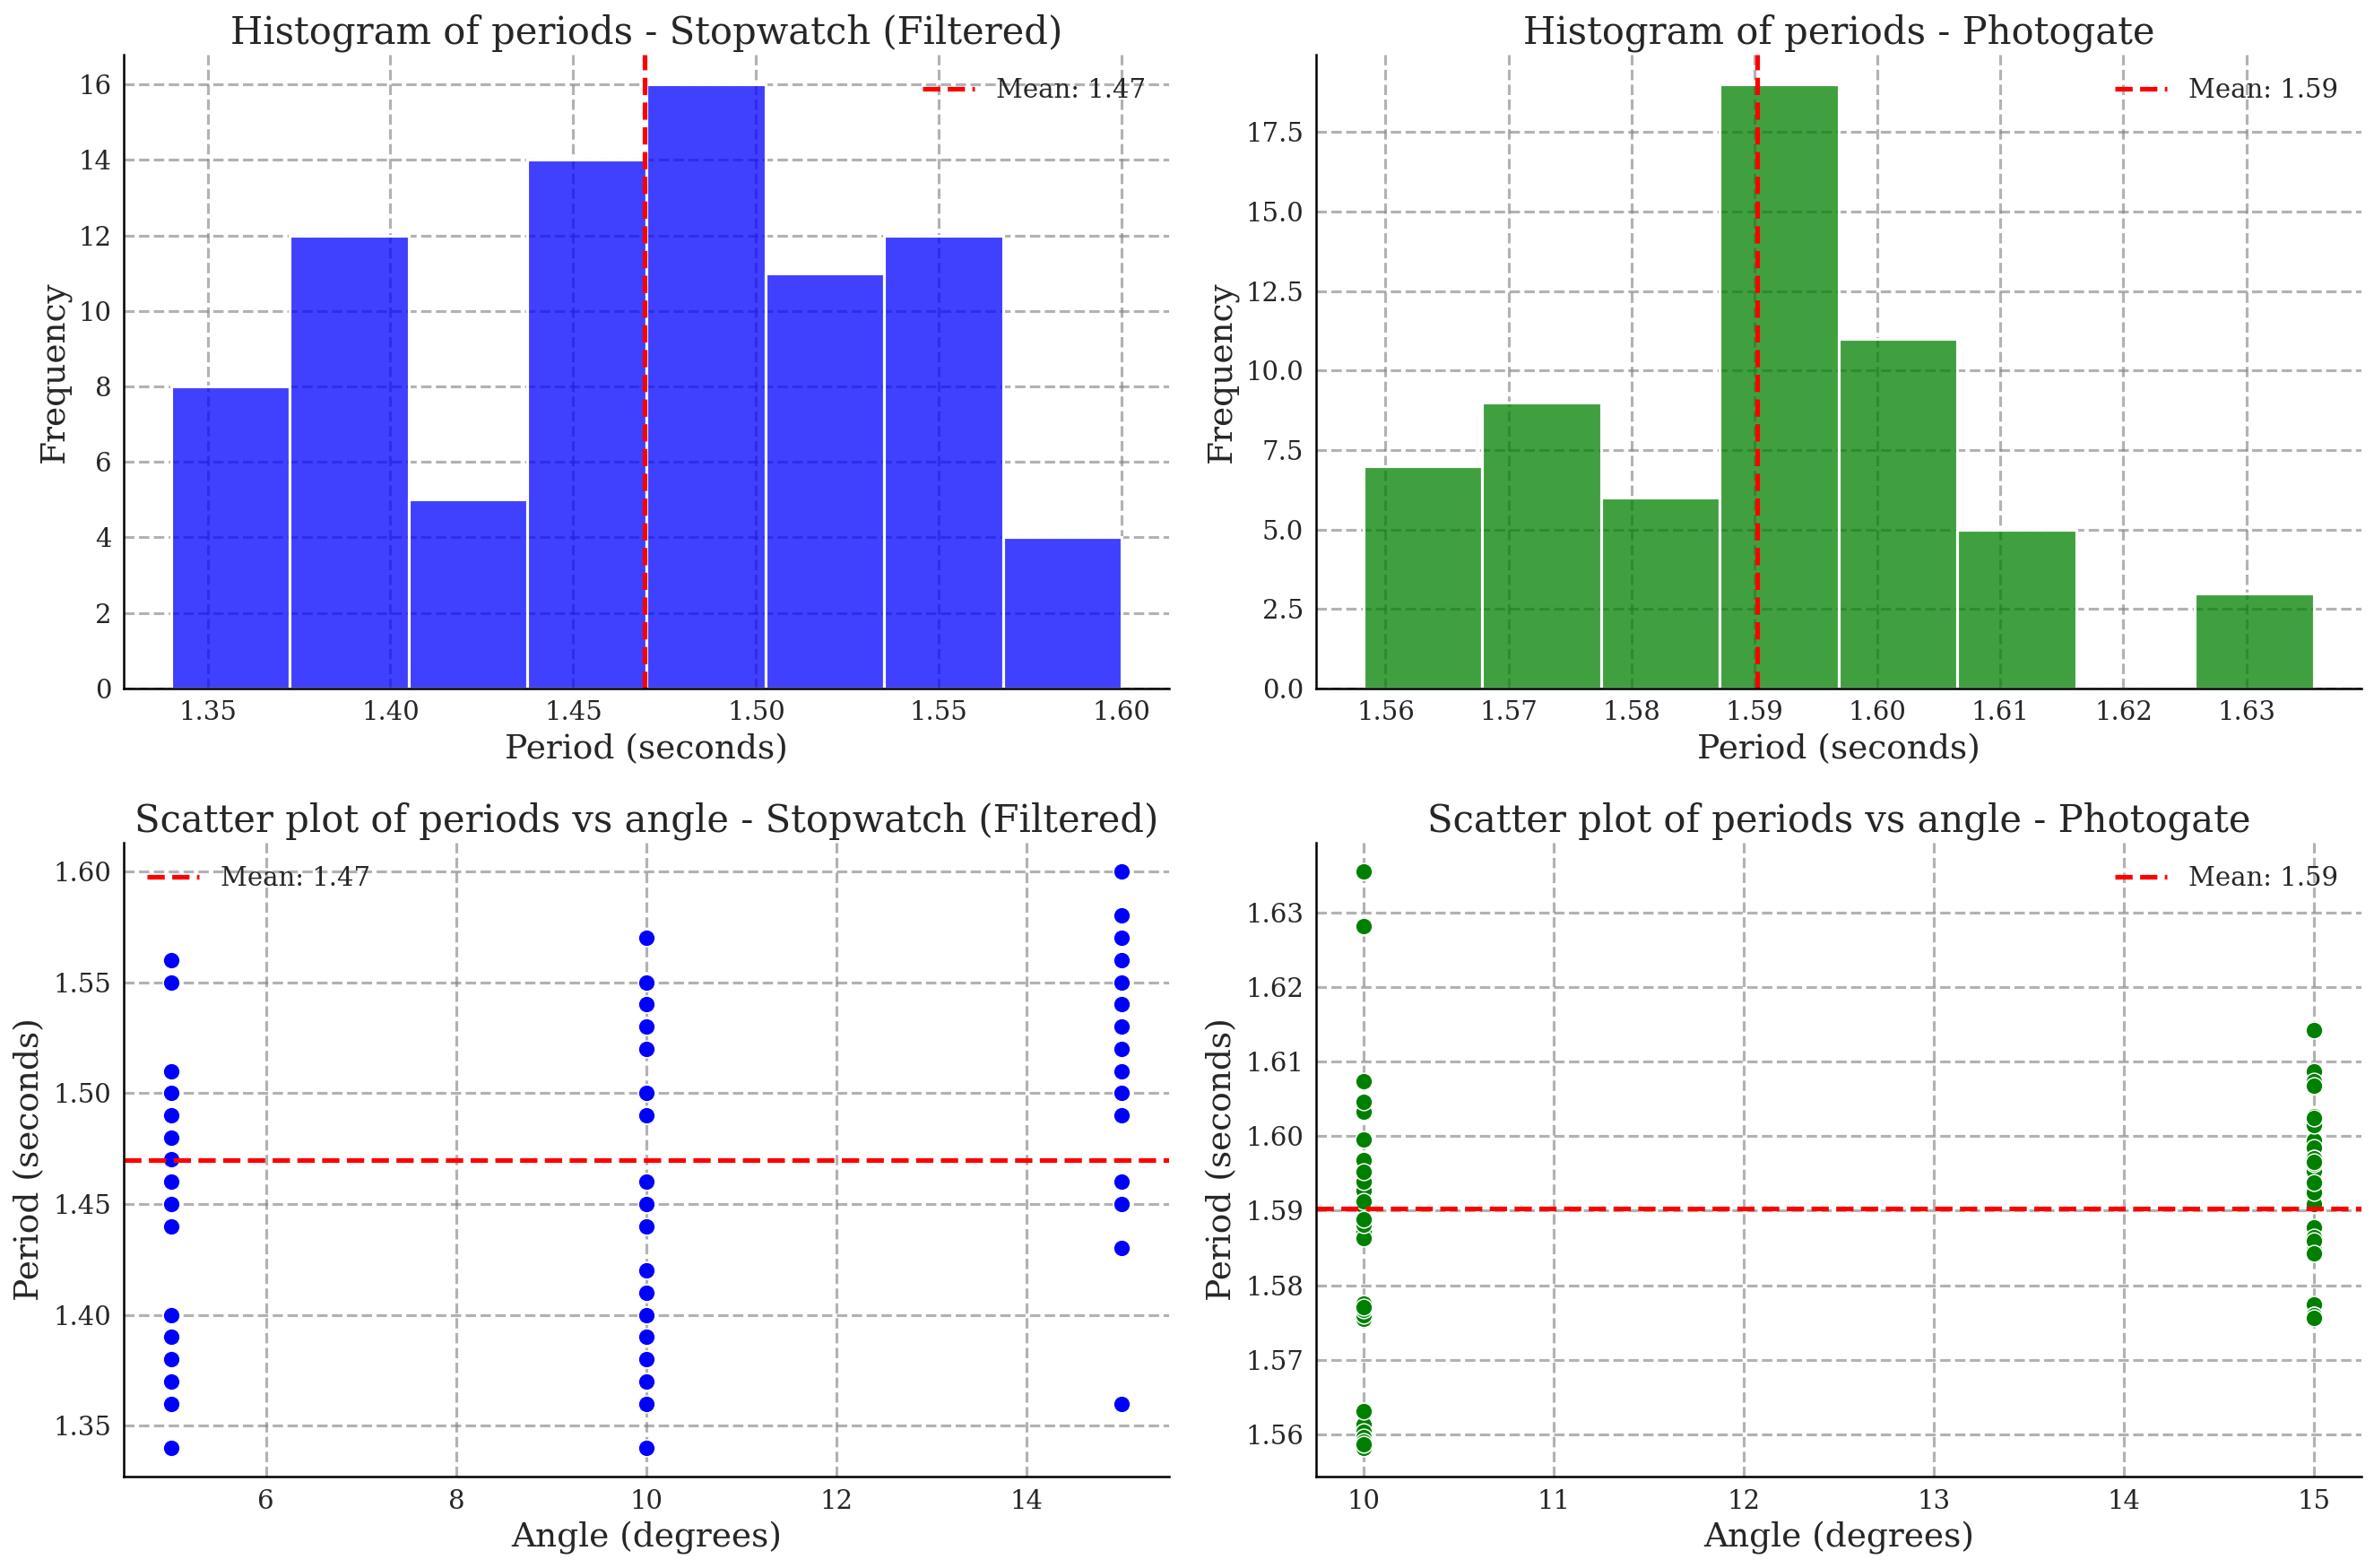

In [5]:
# Filter stopwatch data
stopwatch_data_filtered = stopwatch_data[(stopwatch_data['period(seconds)'] <= 1.6) & (stopwatch_data['period(seconds)'] >= 1.3)]

# Calculate the period means
mean_stopwatch_filtered = stopwatch_data_filtered['period(seconds)'].mean()
mean_photogate = photogate_data['period(seconds)'].mean()

# Create a figure with 4 subplots
plt.figure(figsize=(18, 12))

# Histogram of filtered stopwatch_data
plt.subplot(2, 2, 1)
sns.histplot(stopwatch_data_filtered['period(seconds)'], kde=False, color='blue')
plt.axvline(mean_stopwatch_filtered, color='red', linestyle='--', label=f'Mean: {mean_stopwatch_filtered:.2f}')
plt.title('Histogram of periods - Stopwatch (Filtered)')
plt.xlabel('Period (seconds)')
plt.ylabel('Frequency')
plt.legend()

# Histogram of photogate_data
plt.subplot(2, 2, 2)
sns.histplot(photogate_data['period(seconds)'], kde=False, color='green')
plt.axvline(mean_photogate, color='red', linestyle='--', label=f'Mean: {mean_photogate:.2f}')
plt.title('Histogram of periods - Photogate')
plt.xlabel('Period (seconds)')
plt.ylabel('Frequency')
plt.legend()

# Scatter plot of filtered stopwatch_data
plt.subplot(2, 2, 3)
sns.scatterplot(x=stopwatch_data_filtered['angle(degrees)'], y=stopwatch_data_filtered['period(seconds)'], color='blue')
plt.axhline(mean_stopwatch_filtered, color='red', linestyle='--', label=f'Mean: {mean_stopwatch_filtered:.2f}')
plt.title('Scatter plot of periods vs angle - Stopwatch (Filtered)')
plt.xlabel('Angle (degrees)')
plt.ylabel('Period (seconds)')
plt.legend()

# Scatter plot of photogate_data
plt.subplot(2, 2, 4)
sns.scatterplot(x=photogate_data['angle(degrees)'], y=photogate_data['period(seconds)'], color='green')
plt.axhline(mean_photogate, color='red', linestyle='--', label=f'Mean: {mean_photogate:.2f}')
plt.title('Scatter plot of periods vs angle - Photogate')
plt.xlabel('Angle (degrees)')
plt.ylabel('Period (seconds)')
plt.legend()

plt.tight_layout()
plt.show()

# Point 3

3. Use the equation from point 1 to determine the acceleration due to gravity for each period. Group the accelerations into groups of 5, 15, and 30 data and perform the following steps with each group: (a) determine the average acceleration and standard error, (b) in the same figure, plot the average value with error bars of one standard error, 3 standard errors, and with the t-student correction for an uncertainty of 0.27%. Include in the plot the accepted value for acceleration g = 977 cm/s². Analyze and conclude about the result for each group and each reported error.

In [6]:
from scipy.stats import t

constant_length = 0.668  # Constant length of the pendulum in meters

def calculate_gravity(period, length):
    # Calculate gravity
    gravity = (4 * np.pi**2 * length) / period**2
    return gravity

def gravity_tests(data, data_groups=[5, 15, 30]):
    g_accepted = 977  # cm/s^2
    g_accepted_m_s2 = g_accepted / 100  # Convert to m/s^2

    fig, axs = plt.subplots(len(data_groups), 1, figsize=(10, 15))
    fig.suptitle('Calculated gravity with different sample sizes and error bars')

    for i, group in enumerate(data_groups):
        # Randomly selecting the number of data
        data_group = data.sample(n=group)
        # print(data_group)
        # Calculating gravity
        gravity = calculate_gravity(data_group['period(seconds)'], constant_length)
        average_acceleration = gravity.mean()
        standard_error = gravity.std() / np.sqrt(group)

        # Calculate t-student correction for an uncertainty of 0.27%
        t_value = t.ppf(1 - 0.0027 / 2, df=group - 1)
        t_student_error = t_value * standard_error

        # Plot
        axs[i].errorbar(1, average_acceleration, yerr=standard_error, fmt='o', label='1 standard error')
        axs[i].errorbar(2, average_acceleration, yerr=3 * standard_error, fmt='o', label='3 standard errors')
        axs[i].errorbar(3, average_acceleration, yerr=t_student_error, fmt='o', label='t-student correction (0.27%)')
        axs[i].axhline(y=g_accepted_m_s2, color='r', linestyle='--', label='accepted g (9.77 m/s²)')
        axs[i].set_title(f'Group of {group} data')
        axs[i].set_xticks([1, 2, 3])
        axs[i].set_xticklabels(['1 standard error', '3 standard errors', 't-student correction'])
        axs[i].set_ylabel('Gravity (m/s²)')
        axs[i].legend()
    fig.text(0.5, 0.04, 'Note: The plots do not start at 0 to better show the changes in error bars', ha='center')
    plt.xlabel('Type of error bar')
    plt.tight_layout(rect=[0, 0.08, 1.5, 0.98])
    plt.show()

Gravity analysis for stopwatch data


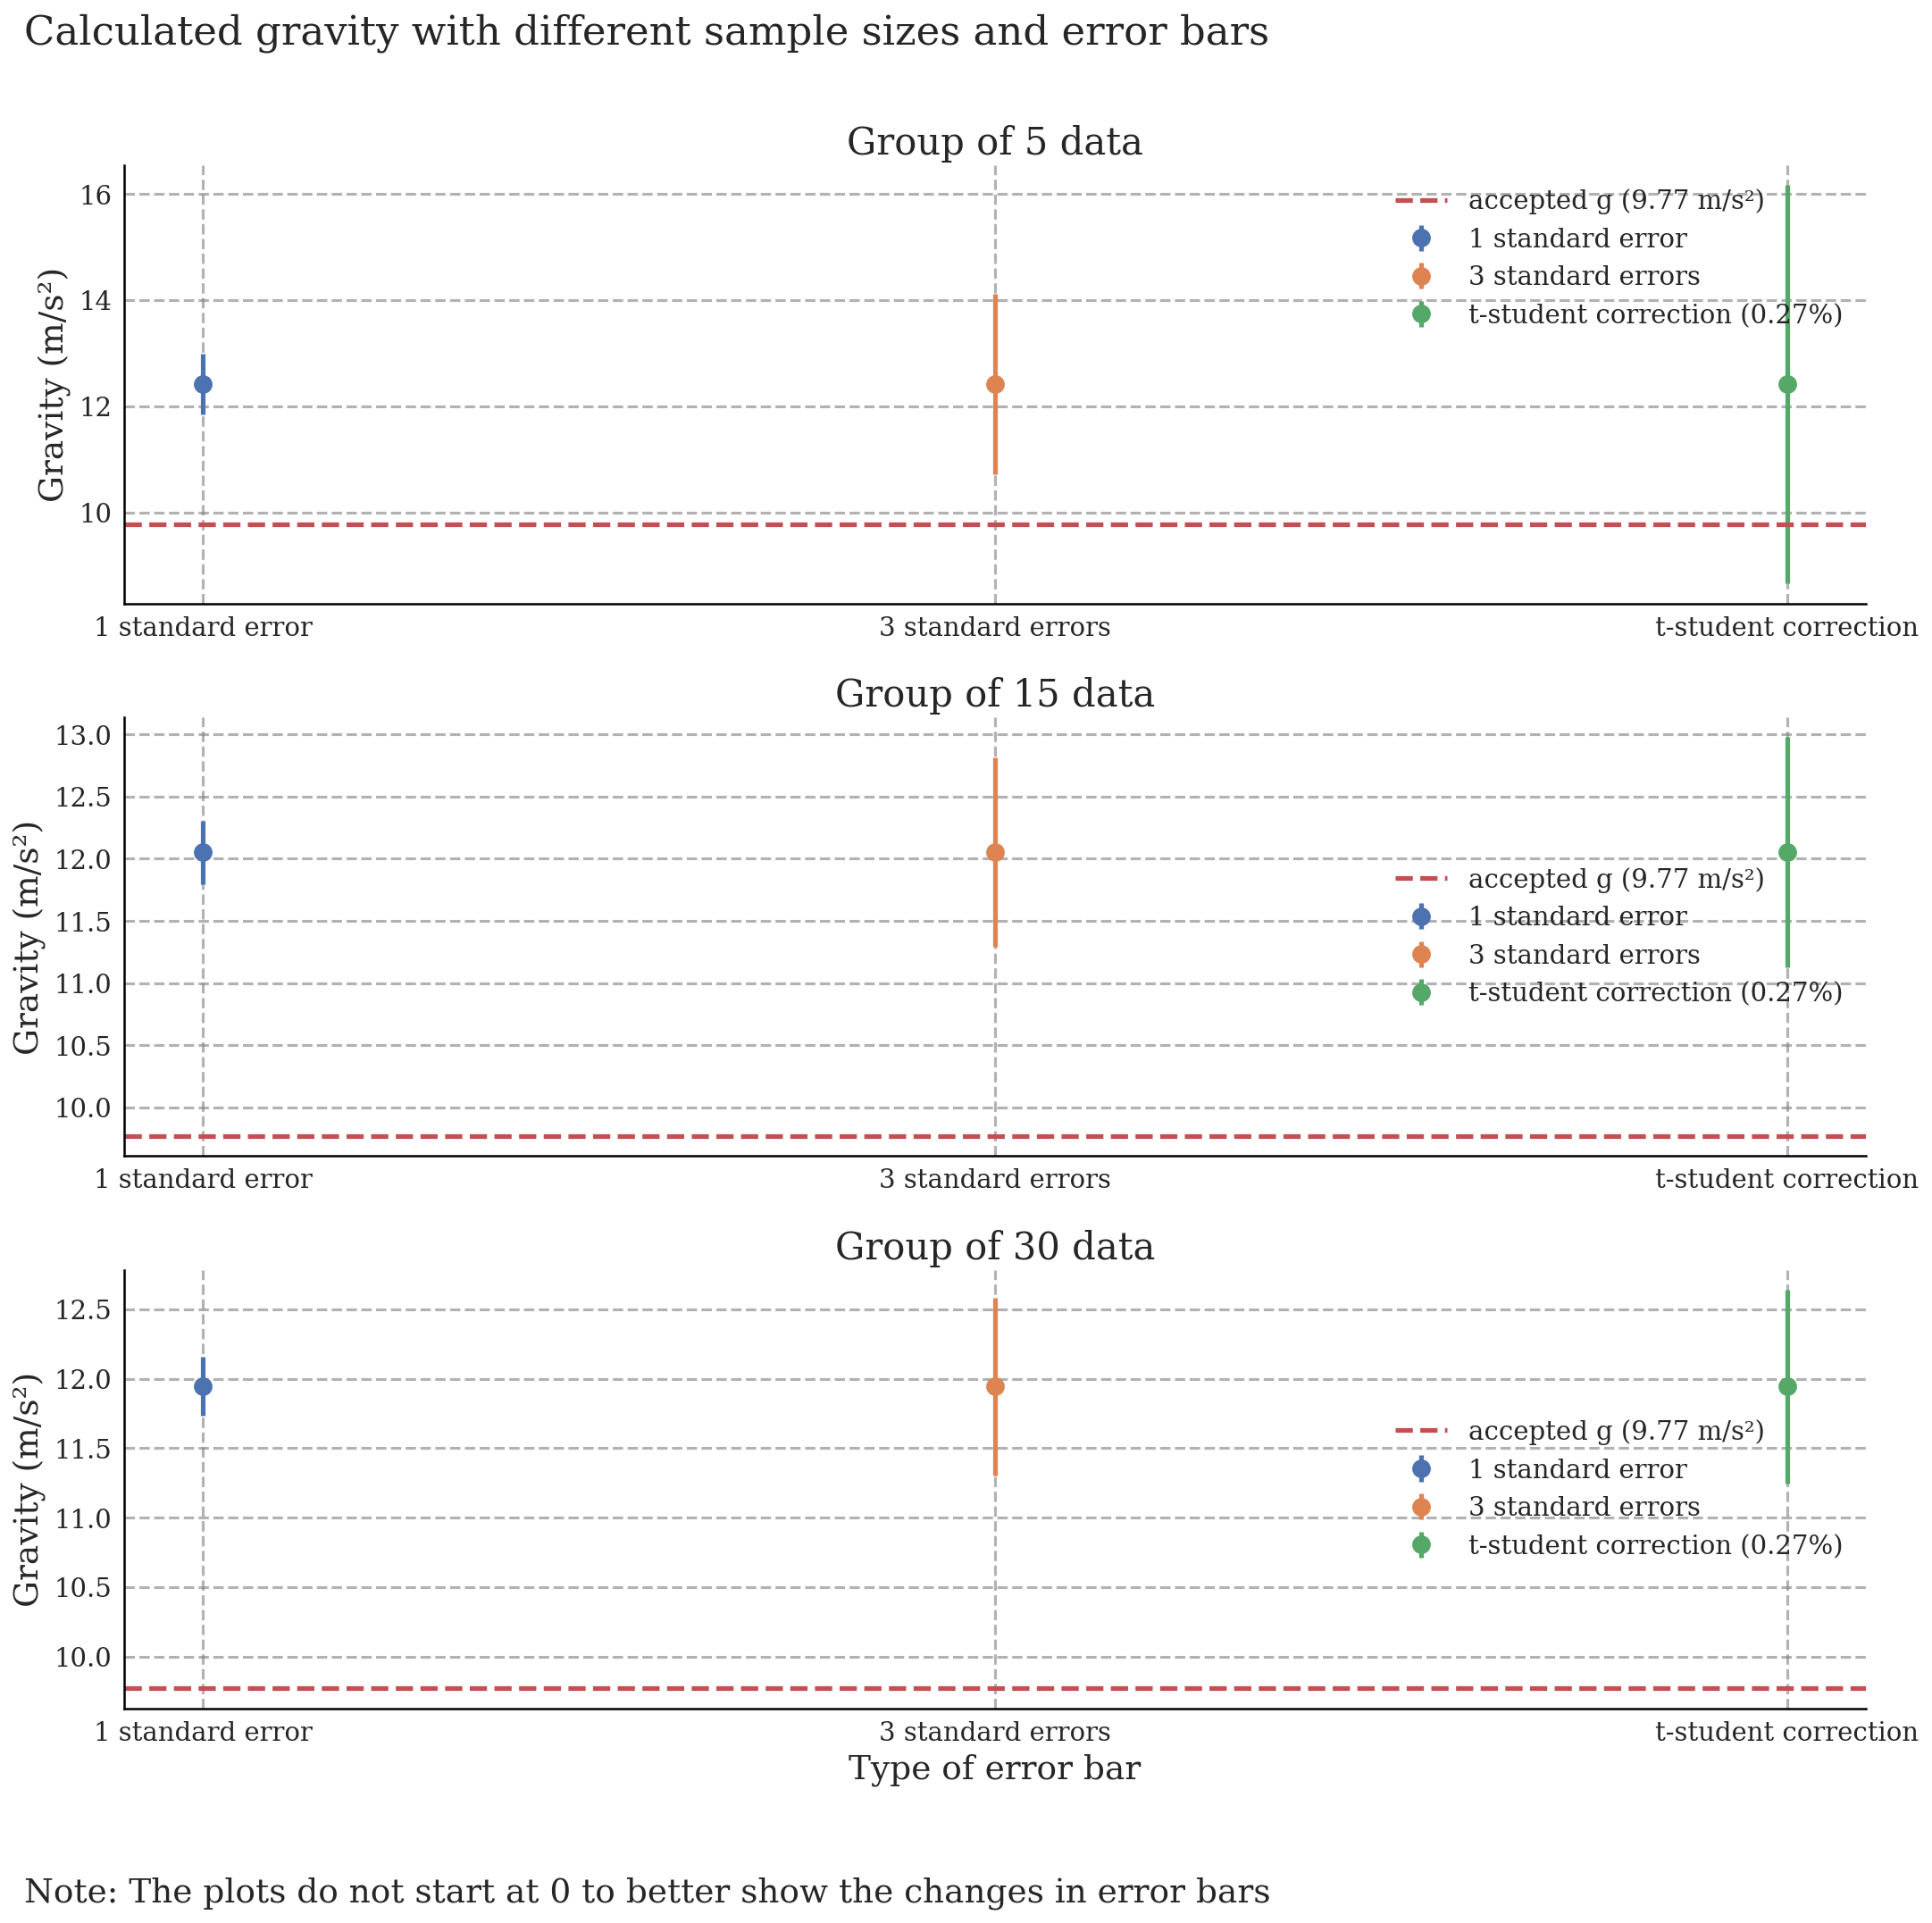

In [7]:
print("Gravity analysis for stopwatch data")
gravity_tests(stopwatch_data_filtered)

Gravity analysis for photogate data


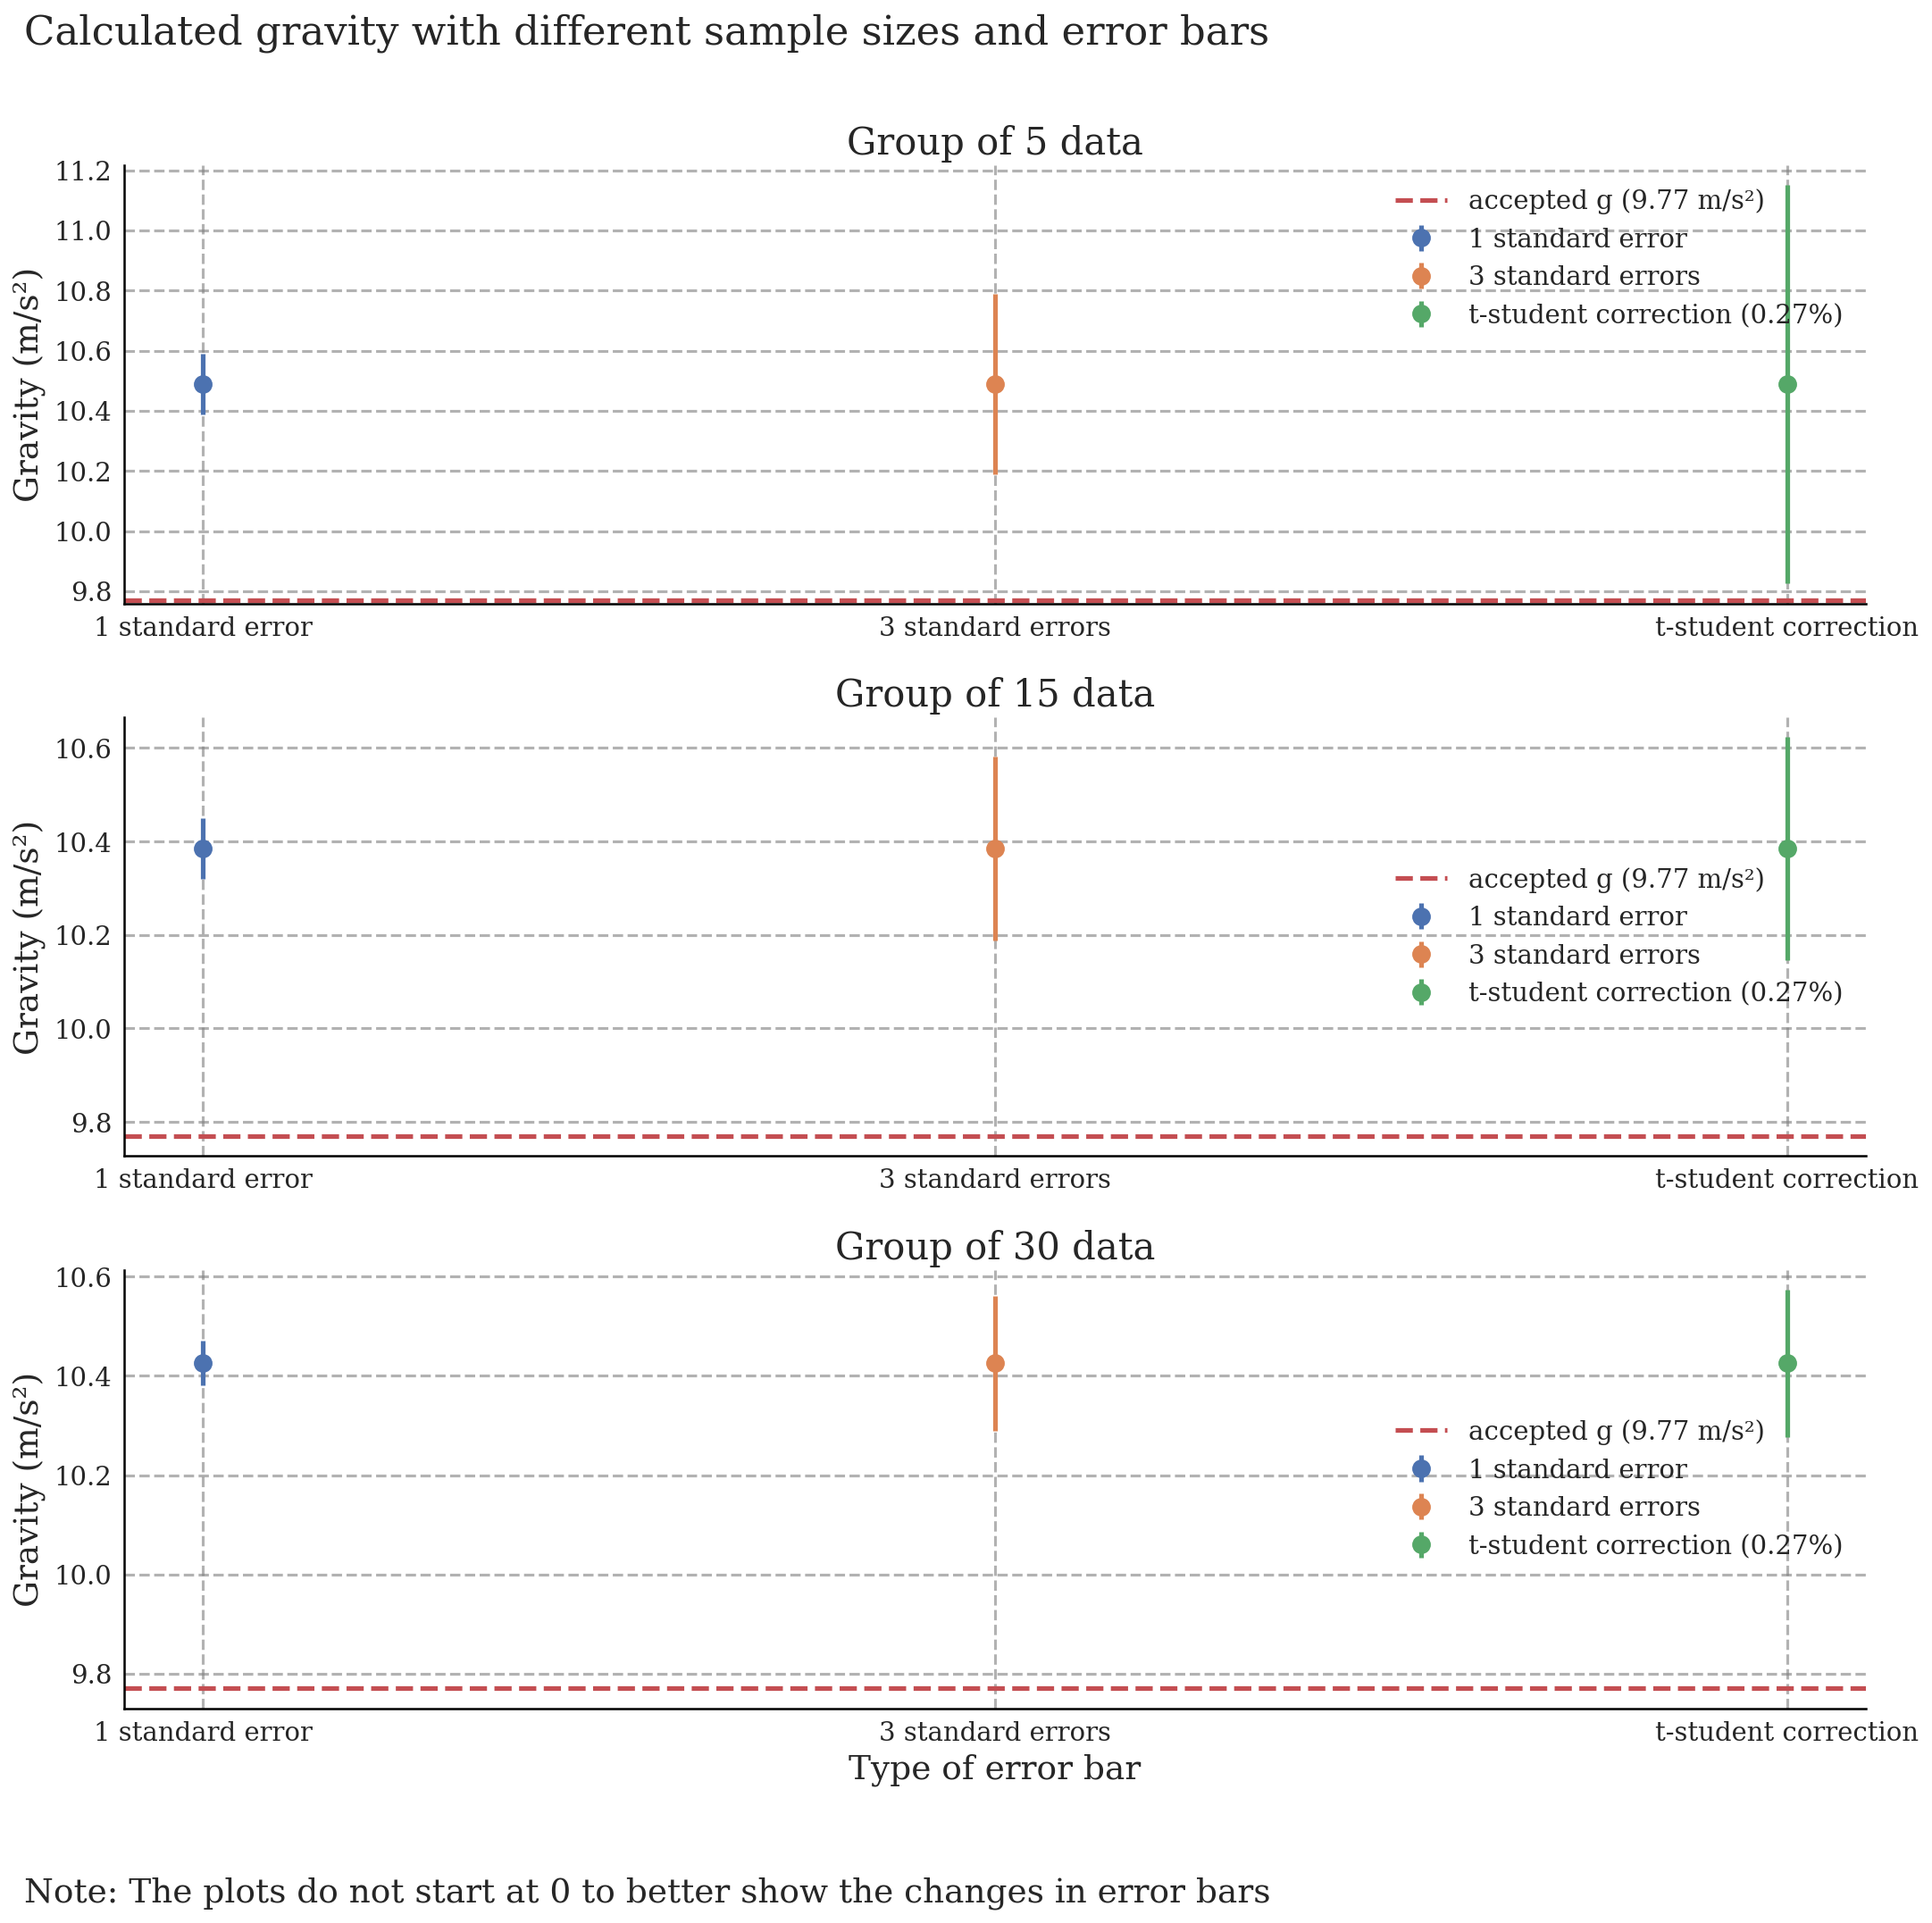

In [8]:
print("Gravity analysis for photogate data")
gravity_tests(photogate_data)

# Point 4

4. Determine the percentage error of the central value for each group with respect to the expected value for Medellín. Analyze and conclude.

In [9]:
def percentage_error(measured_value, theoretical_value):
    return abs((measured_value - theoretical_value) / theoretical_value) * 100

def analyze_groups(data, data_groups=[5, 10, 15]):
    g_accepted = 977  # cm/s^2
    g_accepted_m_s2 = g_accepted / 100  # Convert to m/s^2

    results = []

    for group in data_groups:
        data_group = data.sample(n=group)  # Randomly select data
        gravity = calculate_gravity(data_group['period(seconds)'], constant_length)

        # Calculate the mean and percentage error with 2 significant figures
        mean = "{:.3g}".format(gravity.mean())
        error_mean = "{:.3g}".format(percentage_error(float(mean), g_accepted_m_s2))

        results.append({
            "Group size": group,
            "Mean (m/s²)": mean,
            "Mean error (%)": error_mean
        })

    df_results = pd.DataFrame(results)
    print(df_results.to_string(index=False))
    return df_results

print("Results with stopwatch data:")
df_stopwatch = analyze_groups(stopwatch_data)

print("\nResults with photogate data:")
df_photogate = analyze_groups(photogate_data)

Results with stopwatch data:
 Group size Mean (m/s²) Mean error (%)
          5        11.5           17.7
         10        12.1           23.8
         15        12.3           25.9

Results with photogate data:
 Group size Mean (m/s²) Mean error (%)
          5        10.5           7.47
         10        10.3           5.42
         15        10.4           6.45


Analyzing the data obtained, there is clear evidence of an improvement in the percentage error of the central value recorded with the photogate compared to that obtained using the stopwatch.

# Point 5

5. It is expected that there is a systematic error due to the measurement of the period. Propose and carry out the experiment in a way that avoids the existence of this factor. Repeat points 2, 3, and 4 with the new measurements. Do you notice any improvement with respect to the previous results? Conclude.

Solution: To minimize systematic errors in measurement, the photogate tool was used, which allowed obtaining more accurate and reliable results. Taking this consideration into account, the experiment has been recorded in points 2, 3, and 4, thus facilitating the comparison of results. The new measurements performed with the photogate provided more coherent and acceptable values, which leads us to conclude that this is the most appropriate tool for determining the acceleration due to gravity in our experiment.

# Point 6

6. Report the acceleration value you obtained with the lowest percentage error and with the t-student correction for an uncertainty of 0.27%.

In [10]:
def best_result(df_results):
    # Convert values in the "Mean error (%)" column to float for comparisons
    df_results["Mean error (%)"] = df_results["Mean error (%)"].astype(float)

    # Find the row with the lowest percentage error
    best_row = df_results.loc[df_results["Mean error (%)"].idxmin()]

    print("\nBest result obtained:")
    print(f"Group size: {int(best_row['Group size'])}")
    print(f"Average acceleration (m/s²): {best_row['Mean (m/s²)']}")
    print(f"Percentage error: {best_row['Mean error (%)']}%")

In [11]:
print("\nResults with stopwatch data:")
best_result(df_stopwatch)

print("\nResults with photogate data:")
best_result(df_photogate)


Results with stopwatch data:

Best result obtained:
Group size: 5
Average acceleration (m/s²): 11.5
Percentage error: 17.7%

Results with photogate data:

Best result obtained:
Group size: 10
Average acceleration (m/s²): 10.3
Percentage error: 5.42%
